In [247]:
import pandas as pd
import matplotlib.pyplot as plt


In [248]:
tax_bracket_df = pd.read_csv('data/historical_tax_brackets.csv')
tax_bracket_df.drop(columns=['Unnamed: 2', 'Unnamed: 5', 'Unnamed: 8', 'Unnamed: 11', 'Notes:'], inplace=True)

tax_bracket_df = tax_bracket_df[['Year', 'Single Filer (Rates/Brackets)', 'Unnamed: 9',
                                 'Head of Household (Rates/Brackets)', 'Unnamed: 12',
                                 'Married Filing Jointly (Rates/Brackets)','Unnamed: 3',
                                 'Married Filing Separately (Rates/Brackets)','Unnamed: 6']]
tax_bracket_df.columns = ['year', 'single_r', 'single_bs', 'hoh_r', 'hoh_bs', 'mfj_r', 'mfj_bs', 'mfs_r', 'mfs_bs']

tax_bracket_df['year'] = tax_bracket_df['year'].astype(str).str.extract(r'(\d{4})')

rate_cols = [c for c in tax_bracket_df.columns if c.endswith('_r')]
backet_start_cols = [c for c in tax_bracket_df.columns if c.endswith('_bs')]

tax_bracket_df[rate_cols] = tax_bracket_df[rate_cols].apply(lambda x: pd.to_numeric(x.str.rstrip('%'), errors='coerce') / 100)
tax_bracket_df[backet_start_cols] = tax_bracket_df[backet_start_cols].apply(lambda x: pd.to_numeric(x.replace(r'[$,]', '', regex=True), errors='coerce'))

tax_bracket_df.dropna(how='all', inplace=True)
tax_bracket_df.fillna(0, inplace=True)

tax_bracket_df.head()

,year,single_r,single_bs,hoh_r,hoh_bs,mfj_r,mfj_bs,mfs_r,mfs_bs
0,2025,0.10,0.0,0.10,0.0,0.10,0.0,0.10,0.0
1,2025,0.12,11925.0,0.12,17000.0,0.12,23850.0,0.12,11925.0
2,2025,0.22,48475.0,0.22,64850.0,0.22,96950.0,0.22,48475.0
3,2025,0.24,103350.0,0.24,103350.0,0.24,206700.0,0.24,103350.0
4,2025,0.32,197300.0,0.32,197300.0,0.32,394600.0,0.32,197300.0


In [249]:
inflation_df = pd.read_csv('data/january_cpi_1913_to_2026.csv')

inflation_df['year'] = inflation_df['year'].astype(str)
inflation_df['cpi'] = inflation_df['cpi'].astype(float)
inflation_df['inflation_adj_ratio'] = inflation_df['cpi'][0] / inflation_df['cpi']

inflation_df.drop(columns=['cpi'], inplace=True)

inflation_df.head()

,year,inflation_adj_ratio
0,2026,1.000000
1,2025,1.023864
2,2024,1.054585
3,2023,1.087181
4,2022,1.156871


In [250]:
inflation_adj_tax_bracket_df = pd.merge(tax_bracket_df, inflation_df, on='year', how='left')
inflation_adj_tax_bracket_df.dropna(inplace=True)

inflation_adj_tax_bracket_df[backet_start_cols] = inflation_adj_tax_bracket_df[backet_start_cols].apply(lambda bs: (bs * inflation_adj_tax_bracket_df['inflation_adj_ratio']).round())
inflation_adj_tax_bracket_df.rename(columns={c: f"adj_{c}" for c in backet_start_cols}, inplace=True)
inflation_adj_tax_bracket_df.drop(columns=['inflation_adj_ratio'], inplace=True)

inflation_adj_tax_bracket_df.head()

,year,single_r,adj_single_bs,hoh_r,adj_hoh_bs,mfj_r,adj_mfj_bs,mfs_r,adj_mfs_bs
0,2025,0.10,0.0,0.10,0.0,0.10,0.0,0.10,0.0
1,2025,0.12,12210.0,0.12,17406.0,0.12,24419.0,0.12,12210.0
2,2025,0.22,49632.0,0.22,66398.0,0.22,99264.0,0.22,49632.0
3,2025,0.24,105816.0,0.24,105816.0,0.24,211633.0,0.24,105816.0
4,2025,0.32,202008.0,0.32,202008.0,0.32,404017.0,0.32,202008.0


In [251]:
def calculate_progressive_tax(income, brackets_df, rate_col, start_col):
    df = brackets_df.sort_values(start_col)
    
    tax_total = 0
    starts = df[start_col].values
    rates = df[rate_col].values
    
    for i in range(len(df)):
        current_start = starts[i]
        current_rate = rates[i]
        next_start = starts[i+1] if i + 1 < len(df) else float('inf')
        
        if income > current_start:
            taxable_in_bracket = min(income, next_start) - current_start
            tax_total += taxable_in_bracket * current_rate
        else:
            break
            
    return tax_total


In [252]:
status_map = {
    'Single': ('single_r', 'adj_single_bs'),
    'Head of Household': ('hoh_r', 'adj_hoh_bs'),
    'Married Filing Jointly': ('mfj_r', 'adj_mfj_bs'),
    'Married Filing Separately': ('mfs_r', 'adj_mfs_bs')
}

def plot_for_taxable_income(taxable_income):
    all_results = []

    for year, group in inflation_adj_tax_bracket_df.groupby('year'):
        year_data = {'year': year}
        for label, (r_col, bs_col) in status_map.items():
            tax = calculate_progressive_tax(taxable_income, group, r_col, bs_col)
            year_data[label] = (tax / taxable_income) * 100
        all_results.append(year_data)

    plot_df = pd.DataFrame(all_results).sort_values('year')

    plt.figure(figsize=(12, 6))

    for status in status_map.keys():
        plt.plot(plot_df['year'], plot_df[status], marker='o', label=status)

    plt.title(f'Effective Federal Tax Rate Over Time (${taxable_income:,} Taxable Income)', fontsize=14)
    plt.ylabel('Effective Tax Rate (%)')
    plt.xlabel('Year')
    plt.legend(title="Filing Status")
    plt.grid(True, linestyle='--', alpha=0.7)

    years = plot_df['year'].unique()
    labels_to_show = [y for y in years if int(y) % 5 == 0]
    plt.xticks(labels_to_show, rotation=45)

    plt.tight_layout()
    plt.show()

def plot_for_incomes_by_status(status_label, income_array):
    r_col, bs_col = status_map[status_label]
    
    all_results = []

    for year, group in inflation_adj_tax_bracket_df.groupby('year'):
        year_data = {'year': year}
        for income in income_array:
            tax = calculate_progressive_tax(income, group, r_col, bs_col)
            year_data[f"${income:,}"] = (tax / income) * 100
        all_results.append(year_data)

    plot_df = pd.DataFrame(all_results).sort_values('year')

    plt.figure(figsize=(12, 6))
    for income in income_array:
        column_name = f"${income:,}"
        plt.plot(plot_df['year'], plot_df[column_name], marker='o', label=column_name)

    plt.title(f'Effective Tax Rate Over Time: {status_label}', fontsize=14)
    plt.ylabel('Effective Tax Rate (%)')
    plt.xlabel('Year')
    plt.legend(title="Taxable Income")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    years = plot_df['year'].unique()
    labels_to_show = [y for y in years if int(y) % 5 == 0]
    plt.xticks(labels_to_show, rotation=45)
    
    plt.tight_layout()
    plt.show()

def plot_top_x_marginal_rate(status_label, income_array, top_x=1000):
    r_col, bs_col = status_map[status_label]
    all_results = []

    for year, group in inflation_adj_tax_bracket_df.groupby('year'):
        year_data = {'year': year}
        for base_income in income_array:
            total_income = base_income + top_x
            
            tax_at_total = calculate_progressive_tax(total_income, group, r_col, bs_col)
            tax_at_base = calculate_progressive_tax(base_income, group, r_col, bs_col)
            
            marginal_tax_amount = tax_at_total - tax_at_base
            marginal_effective_rate = (marginal_tax_amount / top_x) * 100
            
            year_data[f"Base ${base_income:,}"] = marginal_effective_rate
            
        all_results.append(year_data)

    plot_df = pd.DataFrame(all_results).sort_values('year')

    plt.figure(figsize=(12, 6))
    for base_income in income_array:
        label = f"Base ${base_income:,}"
        plt.plot(plot_df['year'], plot_df[label], marker='o', label=label)

    plt.title(f'Effective Tax Rate on the TOP ${top_x:,} of Income ({status_label})', fontsize=14)
    plt.ylabel('Marginal Effective Rate (%)')
    plt.xlabel('Year')
    plt.legend(title="Starting Income Level")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    years = plot_df['year'].unique()
    labels_to_show = [y for y in years if int(y) % 5 == 0]
    plt.xticks(labels_to_show, rotation=45)
    
    plt.tight_layout()
    plt.show()


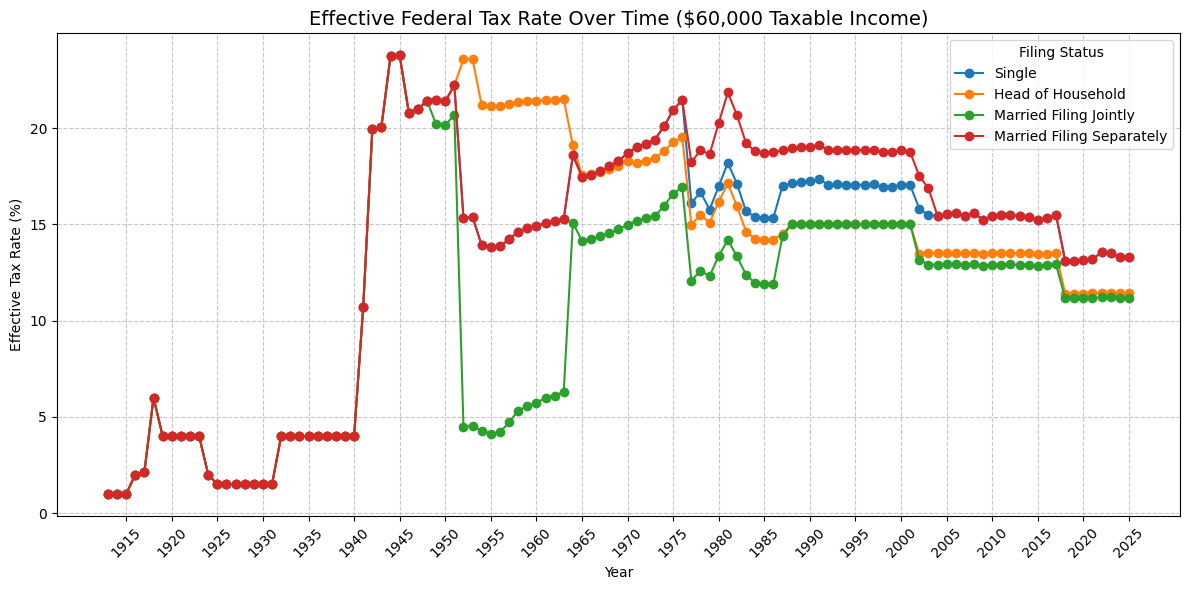

In [253]:
plot_for_taxable_income(60_000)

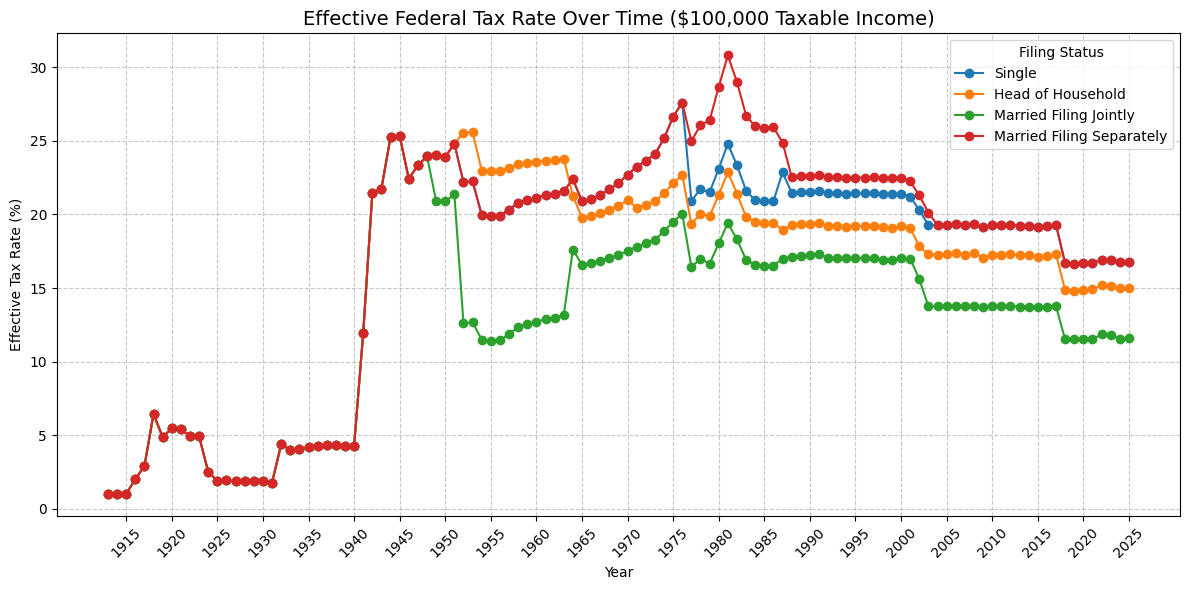

In [254]:
plot_for_taxable_income(100_000)

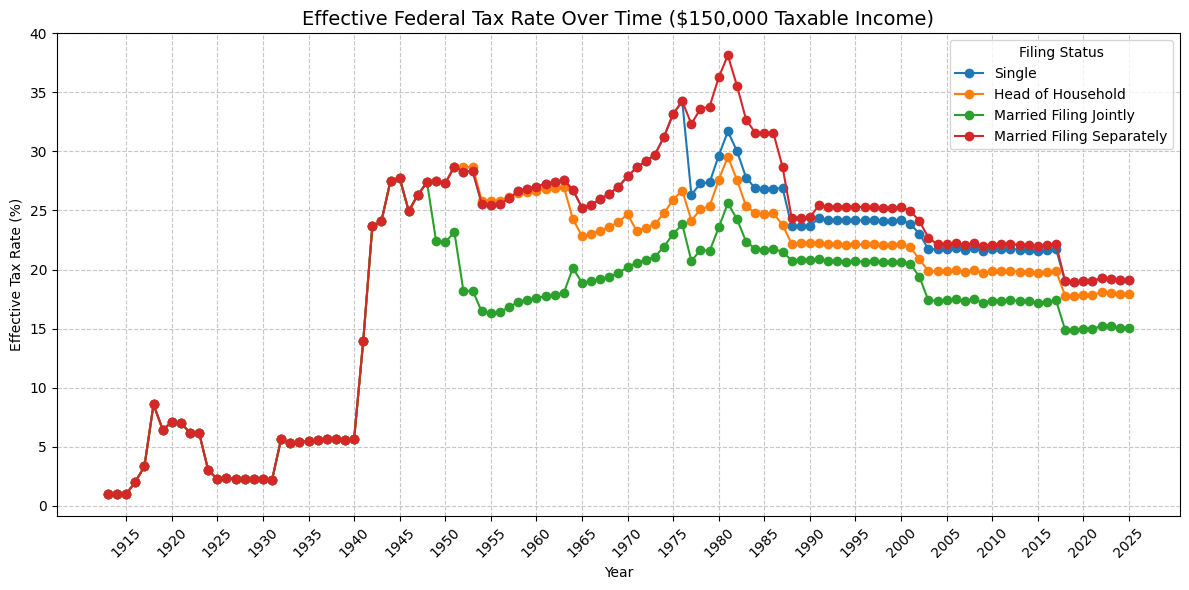

In [255]:
plot_for_taxable_income(150_000)

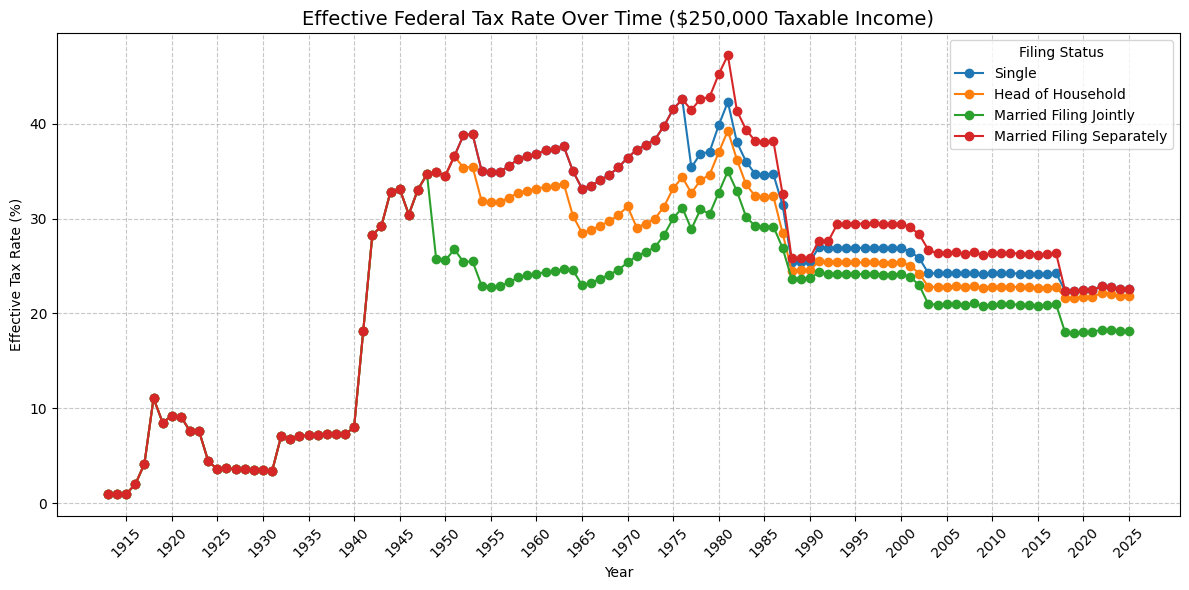

In [256]:
plot_for_taxable_income(250_000)

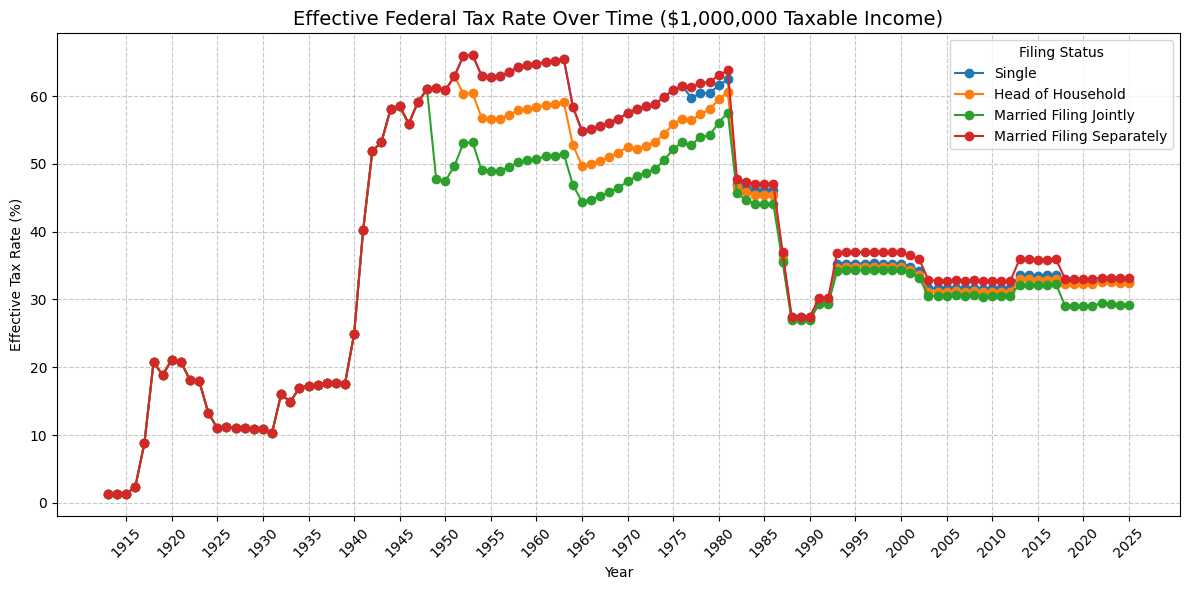

In [257]:
plot_for_taxable_income(1_000_000)

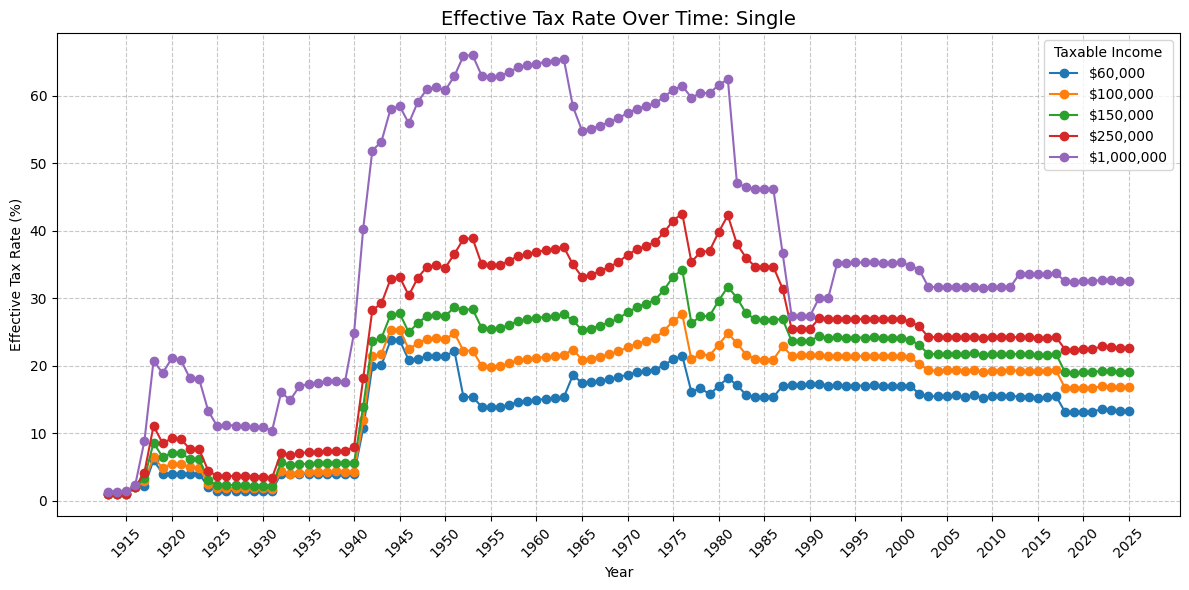

In [258]:
plot_for_incomes_by_status('Single', [60_000, 100_000, 150_000, 250_000, 1_000_000])

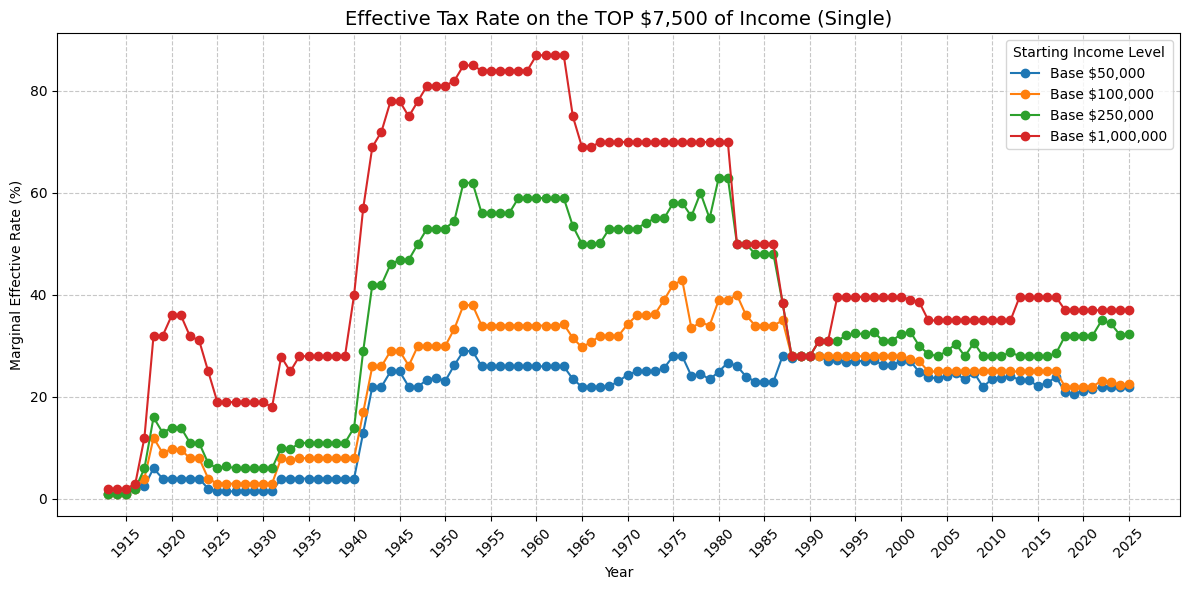

In [265]:
plot_top_x_marginal_rate('Single', [50_000, 100_000, 250_000, 1_000_000], 7500)